# Quickstart: ERA5 Atmosphere

In this notebook, we'll use ERA5 reanalysis data from Google Cloud Storage to construct realistic atmospheric profiles for our simulations. Instead of relying on standard atmosphere models, we can simulate radiation transfer using actual temperature, humidity, and pressure profiles from a specific time and location.

## Setup

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import gcsfs
import os
import logging
from pathlib import Path
from pyradtran.config import load_config

import pyradtran  # Registers the .pyradtran xarray accessor

# Suppress verbose solver output
logging.getLogger('pyradtran').setLevel(logging.DEBUG)

## Loading ERA5 Data

We use the [ARCO ERA5](https://cloud.google.com/storage/docs/public-datasets/era5) dataset hosted on Google Cloud Storage. ARCO (Analysis-Ready, Cloud-Optimized) ERA5 is a reformatted copy of ECMWF's ERA5 reanalysis stored in Zarr format, making it fast to access directly from the cloud without downloading large files. This gives us access to global atmospheric profiles (temperature, humidity, pressure, etc.) at 0.25° resolution and hourly timesteps.

In [8]:
# pip install gcsfs  # Required for accessing ERA5 data from Google Cloud

gcs = gcsfs.GCSFileSystem(token="anon")

# Common ARCO ERA5 Zarr (newer "v3" store; large, but actively used)
path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds = xr.open_zarr(
    gcs.get_mapper(path),
    chunks="auto",
    consolidated=True,
)

In [9]:
ds_sel = ds.sel(time='2017-05-03T12:00:00', latitude=51.33962, longitude=12.37129, method='nearest')
ds.close()
ds_sel

<xarray.Dataset> Size: 3kB
Dimensions:                                                          (level: 37)
Coordinates:
    latitude                                                         float32 4B ...
  * level                                                            (level) int64 296B ...
    longitude                                                        float32 4B ...
    time                                                             datetime64[ns] 8B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         float32 4B dask.array<chunksize=(), meta=np.ndarray>
    100m_v_component_of_wind                                         float32 4B dask.array<chunksize=(), meta=np.ndarray>
    10m_u_component_of_neutral_wind                                  float32 4B dask.array<chunksize=(), meta=np.ndarray>
    10m_u_component_of_wind                                          float32 4B dask.array<chunksize=(), meta=np.ndarray>
    10m_v_component_of_neutral_wind                                  float32 4B dask.array<chunksize=(), meta=np.ndarray>
    10m_v_component_of_wind                                          float32 4B dask.array<chunksize=(), meta=np.ndarray>
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    wave_spectral_directional_width_for_wind_waves                   float32 4B dask.array<chunksize=(), meta=np.ndarray>
    wave_spectral_kurtosis                                           float32 4B dask.array<chunksize=(), meta=np.ndarray>
    wave_spectral_peakedness                                         float32 4B dask.array<chunksize=(), meta=np.ndarray>
    wave_spectral_skewness                                           float32 4B dask.array<chunksize=(), meta=np.ndarray>
    zero_degree_level                                                float32 4B dask.array<chunksize=(), meta=np.ndarray>
Attributes:
    last_updated:           2026-04-18 02:38:53.794831+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-04-12

In [10]:
era5_to_sim = ds_sel.rename({
    'sea_surface_temperature': 'surface_temperature',
    'temperature': 't',
    'specific_humidity': 'q',
    'geopotential': 'z',
    'level': 'pressure_level',
    'time' : 'valid_time',
})

era5_to_sim['time'] = era5_to_sim['valid_time']
# add proper units and convert to SI
era5_to_sim['t'].attrs['units'] = 'K'
era5_to_sim['q'].attrs['units'] = 'kg/kg'
era5_to_sim['pressure_level'].attrs['units'] = 'hPa'

era5_to_sim = era5_to_sim[['pressure_level', 't', 'q', 'z']].load() # these are the three required vars, all need units; load to memory

# these are the only three variables read by the pyRadtran ERA5 interface:
# - t: temperature in K
# - q: specific humidity in kg/kg or RH in %
# - pressure_level: pressure level in hPa or Pa

ds_to_sim = xr.Dataset(
    coords={
        'time': [pd.to_datetime('2017-05-03T12:00:00')],
        'latitude': ('time', [51.34]),
        'longitude': ('time', [12.37]),
        'altitude': ('altitude', np.arange(0, 100, 1)), # simulate a profile from ground to TOA
    },
    data_vars={
        'albedo': ('time', [0.4]),
    }
)


## Running the Simulation

We pass the prepared ERA5 atmospheric profiles to pyRadtran's simulation engine via the `era5_atmosphere` parameter.

In [11]:
# Load the configuration from the YAML file
config_path = Path('config/thermal_config.yaml')

ds_sim = ds_to_sim.pyradtran.run(
    config_path=config_path,
    return_dataset=True,
    save_to_file=False,
    era5_atmosphere=era5_to_sim,  # Use the local ERA5 data
    show_progress=True,
)

2026-04-19 00:52:47,771 - pyradtran.interface - INFO - ERA5 atmosphere dataset validated with 37 pressure levels
2026-04-19 00:52:47,771 - pyradtran.interface - INFO - Altitude found as coordinate - using 100 levels for zout: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]
2026-04-19 00:52:47,807 - pyradtran.interface - INFO - Preparing 1 simulations from input dataset with dims ['time']
2026-04-19 00:52:47,808 - pyradtran.interface - INFO - Creating ERA5 atmosphere files for simulation points...
2026-04-19 00:52:47,811 - pyradtran.io - INFO - Created ERA5 atmosphere file: pyradtran_work/era5_atmospheres/era5_atm_20170503_120000_51.34_12.37.dat with H2O unit kg/kg
2026-04-19 00:52:47,812 - pyradtran.interface - DEBUG - Created/Found

## Distance between Requested Point and Nearest ERA5 Point

Compare the distance between the requested point and the nearest ERA5 point with the `haversine` function.

In [12]:

def haversine(lon1, lat1, lon2, lat2):
    # convert decimal degrees to radians
    lon1 = np.deg2rad(lon1)
    lon2 = np.deg2rad(lon2)
    lat1 = np.deg2rad(lat1)
    lat2 = np.deg2rad(lat2)

    # haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371
    return c * r

In [13]:
requested_lat, requested_lon = 51.33962, 12.37129

distance = haversine(
    requested_lon,
    requested_lat,
    float(ds_sel['longitude'].values),
    float(ds_sel['latitude'].values),
)

print(f"Distance to nearest ERA5 grid point: {distance:.2f} km")

Distance to nearest ERA5 grid point: 13.05 km


## Results

The simulation results are stored in an xarray `Dataset`, so we can use xarray's built-in plotting capabilities to visualize them.

In [14]:
era5_to_sim.t

<xarray.DataArray 't' (pressure_level: 37)> Size: 148B
array([269.21756, 271.29367, 259.31146, 245.09512, 238.15039, 228.60904,
       217.34558, 217.59918, 216.50688, 219.38414, 220.26047, 220.62115,
       221.6331 , 220.3996 , 220.55617, 217.50273, 215.13672, 222.41501,
       231.83176, 239.19899, 245.0441 , 250.26115, 255.10603, 259.38037,
       262.87122, 266.6148 , 270.6865 , 272.26868, 273.42642, 273.9855 ,
       275.04333, 277.06726, 279.27533, 281.3217 , 283.41446, 285.53494,
       287.72833], dtype=float32)
Coordinates:
  * pressure_level  (pressure_level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
    latitude        float32 4B 51.25
    longitude       float32 4B 12.25
    valid_time      datetime64[ns] 8B 2017-05-03T12:00:00
Attributes:
    long_name:      Temperature
    short_name:     t
    standard_name:  air_temperature
    units:          K

Text(0.5, 0, 'Irradiance (W$\\,$m$^{-2}$)')

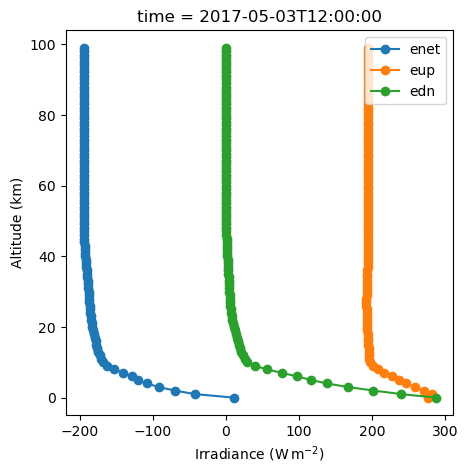

In [31]:
fig, ax = plt.subplots(1, figsize=(5, 5))

ds_sim.enet.plot(
    y='altitude',
    marker='o',
    ax=ax,
)

ds_sim.eup.plot(
    y='altitude',
    marker='o',
    ax=ax,
)

ds_sim.edn.plot(
    y='altitude',
    marker='o',
    ax=ax,
)

ax.legend(['enet', 'eup', 'edn'], loc='upper right')
ax.set_ylabel('Altitude (km)')
ax.set_xlabel(r'Irradiance (W$\,$m$^{-2}$)')
